# MVTec AD - what four categories of component photograph contain

**Arkon Manufacturing AI | Module: CV Anomaly | Department: Component Inspection**

Module 05 of the Arkon platform, and the first one that is not a classifier.
MVTec AD ships photographs of manufactured components in two kinds of folder: a
`train/` folder holding only sound parts, and a `test/` folder holding sound
parts mixed with defective ones. A model here never sees a defect while it is
being fitted. It learns what normal looks like and reports how far a new part
sits from it.

That changes what this notebook has to establish. There is no class balance to
check, because there is only one class in the training data. What matters
instead is whether the four categories are one problem or four, how much of a
frame a defect actually occupies, and whether the folder the module will score
once is genuinely unseen.

The four categories in this subset are `grid`, `metal_nut`, `screw` and
`transistor`.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


## 1. Imports and configuration

Nothing is imported from a training script, because this module has none. The
three notebooks in this folder are the whole of it.

In [2]:
import hashlib
import platform
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.style.use('seaborn-v0_8-darkgrid')

ASSETS = 'cv'
RAW_DIR = Path('../../../data/05_mvtec/raw')
CATEGORIES = sorted(d.name for d in RAW_DIR.iterdir() if d.is_dir())

pd.set_option('display.width', 120)
print(f'python  {sys.version.split()[0]}')
print(f'machine {platform.system()} {platform.machine()}')
# Relative to the repository root. An absolute path is this machine's directory
# layout, it resolves nowhere else, and a notebook's output is tracked.
print(f'data    {RAW_DIR.resolve().relative_to(Path("../../..").resolve()).as_posix()}')
print(f'categories ({len(CATEGORIES)}): {CATEGORIES}')

python  3.12.10
machine Windows AMD64
data    data/05_mvtec/raw
categories (4): ['grid', 'metal_nut', 'screw', 'transistor']


## 2. What the folders hold

Every image is counted rather than sampled. The structure is the same in all
four categories: `train/good` holds sound parts only, `test/` holds one
sub-folder per defect type plus a `good` sub-folder, and `ground_truth/` holds a
segmentation mask for every defective test image.

In [3]:
rows = []
for category in CATEGORIES:
    root = RAW_DIR / category
    for split in ('train', 'test'):
        for folder in sorted((root / split).iterdir()):
            if folder.is_dir():
                rows.append({'category': category, 'split': split, 'group': folder.name,
                             'images': len(list(folder.glob('*.png')))})

inventory = pd.DataFrame(rows)
totals = inventory.pivot_table(index='category', columns='split', values='images',
                               aggfunc='sum', fill_value=0)
totals['test_good'] = [int(inventory[(inventory.category == c) & (inventory.split == 'test')
                                     & (inventory.group == 'good')]['images'].sum())
                       for c in totals.index]
totals['test_defect'] = totals['test'] - totals['test_good']
totals['defect_types'] = [int(((inventory.category == c) & (inventory.split == 'test')
                               & (inventory.group != 'good')).sum()) for c in totals.index]
totals = totals.rename(columns={'train': 'train_good', 'test': 'test_all'})
print(totals[['train_good', 'test_all', 'test_good', 'test_defect', 'defect_types']].to_string())
print()
print(f'{int(totals["train_good"].sum())} sound parts to learn normality from, '
      f'{int(totals["test_all"].sum())} test images of which '
      f'{int(totals["test_defect"].sum())} are defective.')

split       train_good  test_all  test_good  test_defect  defect_types
category                                                              
grid               264        78         21           57             5
metal_nut          220       115         22           93             4
screw              320       160         41          119             5
transistor         213       100         60           40             4

1017 sound parts to learn normality from, 453 test images of which 309 are defective.


In [4]:
print(inventory[inventory.split == 'test'].pivot_table(
    index='group', columns='category', values='images', fill_value=0).to_string())
print()
print('The defect types do not repeat across categories: each category has its own')
print('failure modes, so there is no shared defect vocabulary to classify against even')
print('if this module were trying to.')

category             grid  metal_nut  screw  transistor
group                                                  
bent                 12.0       25.0    0.0         0.0
bent_lead             0.0        0.0    0.0        10.0
broken               12.0        0.0    0.0         0.0
color                 0.0       22.0    0.0         0.0
cut_lead              0.0        0.0    0.0        10.0
damaged_case          0.0        0.0    0.0        10.0
flip                  0.0       23.0    0.0         0.0
glue                 11.0        0.0    0.0         0.0
good                 21.0       22.0   41.0        60.0
manipulated_front     0.0        0.0   24.0         0.0
metal_contamination  11.0        0.0    0.0         0.0
misplaced             0.0        0.0    0.0        10.0
scratch               0.0       23.0    0.0         0.0
scratch_head          0.0        0.0   24.0         0.0
scratch_neck          0.0        0.0   25.0         0.0
thread               11.0        0.0    0.0     

## 3. One dataset or four imaging setups

This is the first question that changes the design, and it is answered by the
files rather than by the dataset description. If the four categories were
photographed the same way, one model could hold all of them. Every image header
is read.

In [5]:
geometry = []
for category in CATEGORIES:
    sizes, modes = Counter(), Counter()
    for path in (RAW_DIR / category).rglob('*.png'):
        if 'ground_truth' in path.parts:
            continue
        with Image.open(path) as image:
            sizes[image.size] += 1
            modes[image.mode] += 1
    sample = np.stack([np.asarray(Image.open(p).convert('L').resize((64, 64)), dtype=np.float32)
                       for p in sorted((RAW_DIR / category / 'train' / 'good').glob('*.png'))])
    geometry.append({'category': category,
                     'images': sum(sizes.values()),
                     'resolution': ' '.join(f'{w}x{h}' for w, h in sizes),
                     'colour_mode': ' '.join(modes),
                     'mean_intensity': round(float(sample.mean()), 1),
                     'std_intensity': round(float(sample.std()), 1)})

geometry = pd.DataFrame(geometry)
print(geometry.to_string(index=False))
print()
print('Two resolutions, two colour modes, and a mean intensity spanning')
print(f'{geometry["mean_intensity"].min():.0f} to {geometry["mean_intensity"].max():.0f} '
      f'on a 0-255 scale. These are four imaging setups, not four views of one.')
print('Every category is internally uniform, which is what makes a per-category')
print('model well posed: normality is a single, tightly controlled appearance.')

  category  images resolution colour_mode  mean_intensity  std_intensity
      grid     342  1024x1024           L           114.2           37.2
 metal_nut     335    700x700         RGB            58.7           42.5
     screw     480  1024x1024           L           184.2           33.6
transistor     313  1024x1024         RGB            77.8           38.8

Two resolutions, two colour modes, and a mean intensity spanning
59 to 184 on a 0-255 scale. These are four imaging setups, not four views of one.
Every category is internally uniform, which is what makes a per-category
model well posed: normality is a single, tightly controlled appearance.


  ✓ Saved → assets\cv\mvtec_eda_samples.png


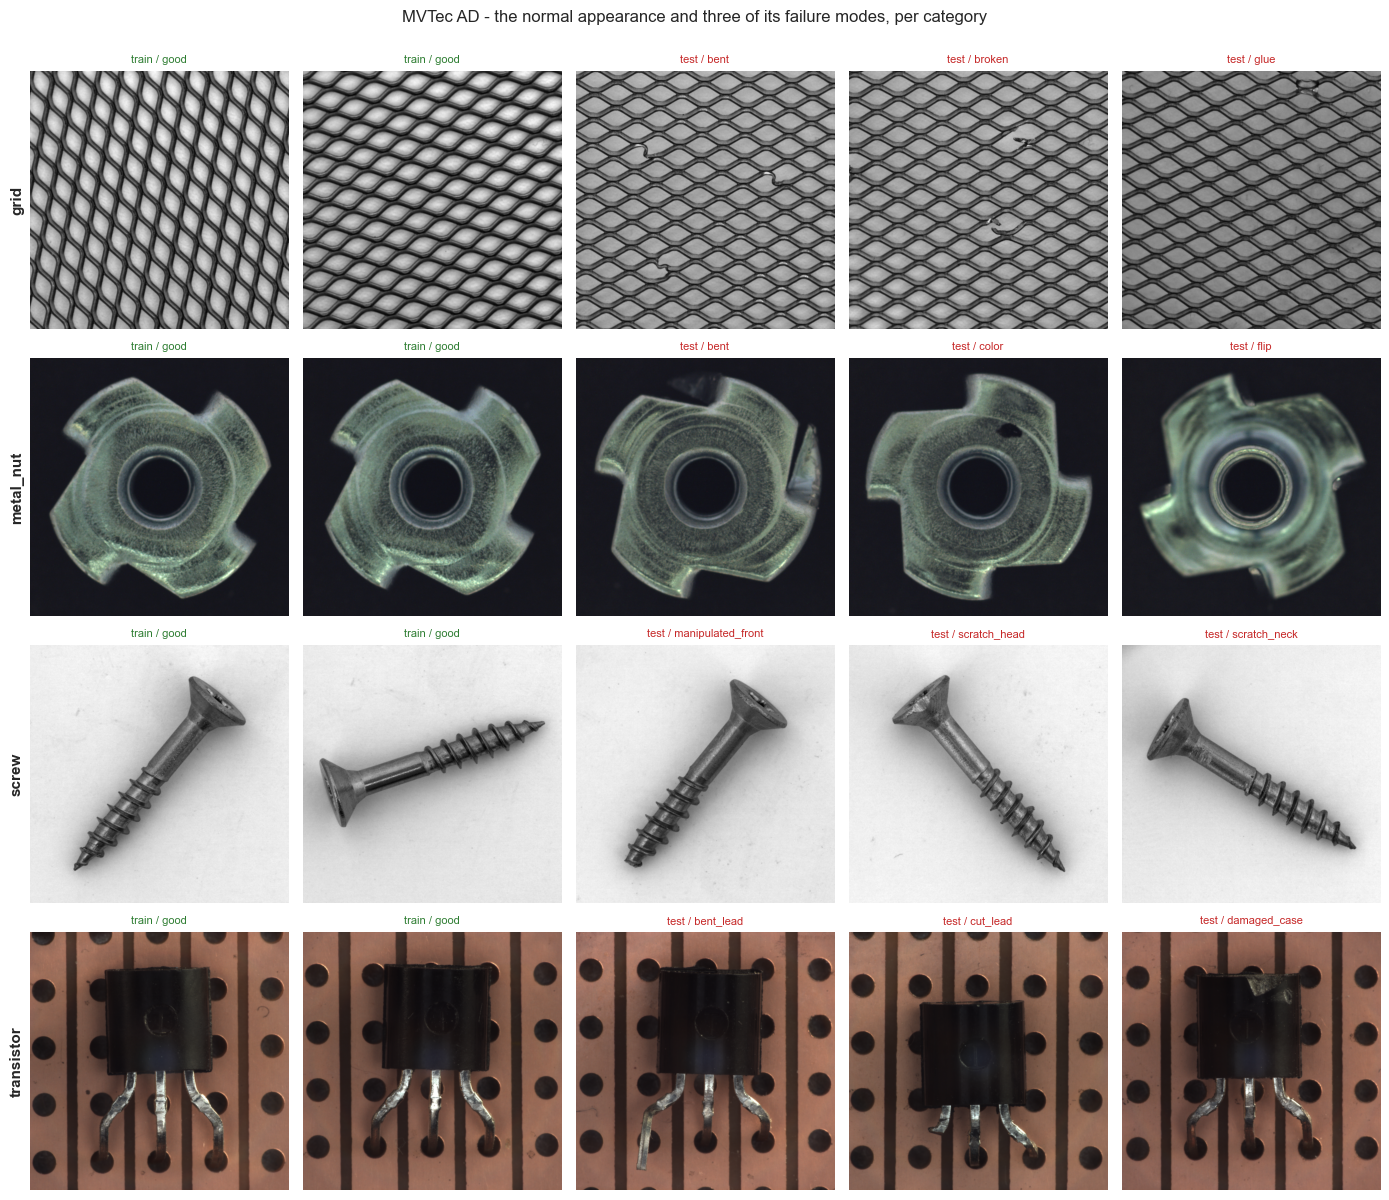

In [6]:
fig, axes = plt.subplots(len(CATEGORIES), 5, figsize=(14, 3.0 * len(CATEGORIES)))
for row, category in enumerate(CATEGORIES):
    root = RAW_DIR / category
    good = sorted((root / 'train' / 'good').glob('*.png'))[:2]
    for column, path in enumerate(good):
        axes[row][column].imshow(Image.open(path), cmap='gray')
        axes[row][column].set_title('train / good', fontsize=8, color='#2e7d32')
    defects = sorted(d for d in (root / 'test').iterdir() if d.is_dir() and d.name != 'good')[:3]
    for column, folder in zip(range(2, 5), defects):
        axes[row][column].imshow(Image.open(sorted(folder.glob('*.png'))[0]), cmap='gray')
        axes[row][column].set_title(f'test / {folder.name}', fontsize=8, color='#c62828')
    for axis in axes[row]:
        axis.set_xticks([])
        axis.set_yticks([])
    axes[row][0].set_ylabel(category, fontsize=11, fontweight='bold')
fig.suptitle('MVTec AD - the normal appearance and three of its failure modes, per category',
             y=1.001)
fig.tight_layout()
save_figure(fig, 'mvtec_eda_samples', subfolder=ASSETS)
plt.show()

## 4. How much of a frame is a defect

The second question that changes the design. This dataset ships a pixel mask for
every defective test image, so the answer is measured rather than estimated. It
decides whether a model can average over a whole frame and still see anything.

In [7]:
mask_rows = []
for category in CATEGORIES:
    for folder in sorted((RAW_DIR / category / 'ground_truth').iterdir()):
        if not folder.is_dir():
            continue
        for path in sorted(folder.glob('*.png')):
            mask = np.asarray(Image.open(path).convert('L'))
            defect_pixels = int((mask > 0).sum())
            mask_rows.append({'category': category, 'defect': folder.name,
                              'stem': path.stem.replace('_mask', ''),
                              'pixels': defect_pixels,
                              'fraction': defect_pixels / mask.size,
                              'frame_pixels': mask.size,
                              'values': len(np.unique(mask))})

masks = pd.DataFrame(mask_rows)
per_type = (masks.groupby(['category', 'defect'])
            .agg(n=('fraction', 'size'), median_fraction=('fraction', 'median'),
                 min_fraction=('fraction', 'min'), max_fraction=('fraction', 'max'),
                 median_pixels=('pixels', 'median'))
            .round({'median_fraction': 4, 'min_fraction': 4, 'max_fraction': 4}))
print(per_type.to_string())
print()
print(f'{len(masks)} masks, all of them binary: '
      f'{sorted(masks["values"].unique())} distinct grey levels per mask.')

                                 n  median_fraction  min_fraction  max_fraction  median_pixels
category   defect                                                                             
grid       bent                 12           0.0099        0.0041        0.0216        10338.0
           broken               12           0.0051        0.0026        0.0232         5329.5
           glue                 11           0.0049        0.0023        0.0073         5125.0
           metal_contamination  11           0.0041        0.0019        0.0082         4249.0
           thread               11           0.0158        0.0070        0.0358        16580.0
metal_nut  bent                 25           0.0187        0.0071        0.0470         9177.0
           color                22           0.0209        0.0044        0.0657        10242.0
           flip                 23           0.4817        0.4785        0.4872       236046.0
           scratch              23           0.055

In [8]:
by_category = masks.groupby('category')['fraction'].median().sort_values()
print('Median share of the frame occupied by a defect, per category:')
for category, fraction in by_category.items():
    side = int(round(np.sqrt(masks[masks.category == category]['pixels'].median())))
    print(f'  {category:11s} {fraction:.4f}   about {side}x{side} pixels of a '
          f'{int(masks[masks.category == category]["frame_pixels"].iloc[0] ** 0.5)}-pixel frame')
print()
structural = per_type[per_type['median_fraction'] > 0.2]
print('Two defect types are not small at all:')
for (category, defect), row in structural.iterrows():
    print(f'  {category}/{defect:10s} median {row["median_fraction"]:.4f} of the frame')
print()
print('Those two are structural rather than surface faults: a nut photographed')
print('upside down and a transistor seated in the wrong place. The part is intact and')
print('its position is wrong, so the mask covers the whole component. Within one')
print('category the defect scale therefore spans two orders of magnitude, which any')
print('single-threshold report has to survive.')

Median share of the frame occupied by a defect, per category:
  screw       0.0029   about 55x55 pixels of a 1024-pixel frame
  grid        0.0060   about 79x79 pixels of a 1024-pixel frame
  transistor  0.0203   about 146x146 pixels of a 1024-pixel frame
  metal_nut   0.0367   about 134x134 pixels of a 700-pixel frame

Two defect types are not small at all:
  metal_nut/flip       median 0.4817 of the frame
  transistor/misplaced  median 0.4045 of the frame

Those two are structural rather than surface faults: a nut photographed
upside down and a transistor seated in the wrong place. The part is intact and
its position is wrong, so the mask covers the whole component. Within one
category the defect scale therefore spans two orders of magnitude, which any
single-threshold report has to survive.


  ✓ Saved → assets\cv\mvtec_eda_masks.png


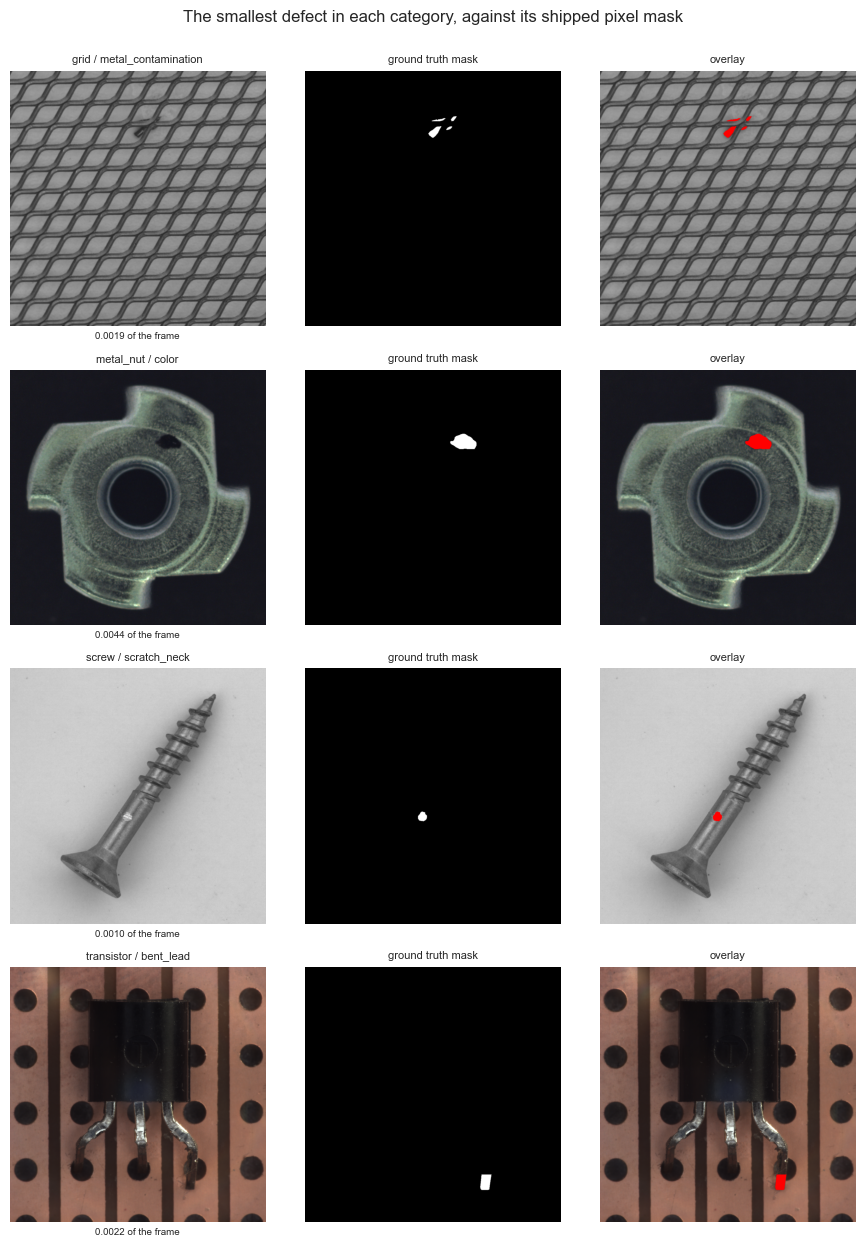

In [9]:
fig, axes = plt.subplots(len(CATEGORIES), 3, figsize=(9, 3.1 * len(CATEGORIES)))
for row, category in enumerate(CATEGORIES):
    subset = masks[masks.category == category].sort_values('fraction')
    smallest = subset.iloc[0]
    folder = RAW_DIR / category / 'test' / smallest['defect']
    mask_folder = RAW_DIR / category / 'ground_truth' / smallest['defect']
    image = Image.open(folder / f'{smallest["stem"]}.png').convert('RGB')
    mask = np.asarray(Image.open(mask_folder / f'{smallest["stem"]}_mask.png').convert('L')) > 0
    overlay = np.asarray(image).copy()
    overlay[mask] = [255, 0, 0]
    for axis, picture, title in zip(axes[row], [image, mask, overlay],
                                    [f'{category} / {smallest["defect"]}', 'ground truth mask',
                                     'overlay']):
        axis.imshow(picture, cmap='gray')
        axis.set_title(title, fontsize=8)
        axis.set_xticks([])
        axis.set_yticks([])
    axes[row][0].set_xlabel(f'{smallest["fraction"]:.4f} of the frame', fontsize=7)
fig.suptitle('The smallest defect in each category, against its shipped pixel mask',
             y=1.001)
fig.tight_layout()
save_figure(fig, 'mvtec_eda_masks', subfolder=ASSETS)
plt.show()

Every mask is checked against its image rather than assumed to exist. A missing
mask would silently become an all-negative region in any localisation score, and
a mask beside a sound part would be a labelling error.

In [10]:
problems = []
for category in CATEGORIES:
    root = RAW_DIR / category
    for folder in sorted(d for d in (root / 'test').iterdir() if d.is_dir()):
        for path in sorted(folder.glob('*.png')):
            mask_path = root / 'ground_truth' / folder.name / f'{path.stem}_mask.png'
            if folder.name == 'good':
                if mask_path.exists():
                    problems.append(f'{category}/{folder.name}/{path.name}: sound part has a mask')
                continue
            if not mask_path.exists():
                problems.append(f'{category}/{folder.name}/{path.name}: defect has no mask')
                continue
            with Image.open(path) as image, Image.open(mask_path) as mask:
                if image.size != mask.size:
                    problems.append(f'{category}/{folder.name}/{path.name}: '
                                    f'mask {mask.size} against image {image.size}')

n_defective = int(totals['test_defect'].sum())
print(f'defective test images : {n_defective}')
print(f'masks shipped         : {len(masks)}')
print(f'problems found        : {len(problems) if problems else "none"}')
for line in problems[:10]:
    print(f'  {line}')
print()
print('Every defective image has exactly one mask at its own resolution, and no sound')
print('part carries one. Sound test images contribute an all-negative region to any')
print('pixel-level score, which is correct and has to be included rather than skipped.')

defective test images : 309
masks shipped         : 309
problems found        : none

Every defective image has exactly one mask at its own resolution, and no sound
part carries one. Sound test images contribute an all-negative region to any
pixel-level score, which is correct and has to be included rather than skipped.


## 5. Does the test folder share images with the training folder

The casting module shipped 64 byte-identical images in both its train and its
test folder and nobody had checked, which flattered its false-alarm rate. The
check is standard here now, and it is done on content rather than on file names,
because casting also showed that names collide across folders without the
pictures being the same.

For this module the check matters in a second way: an anomaly detector's memory
bank is the training folder, so a leaked sound image would be compared against a
copy of itself and score as perfectly normal.

In [11]:
def digests(path):
    """File bytes and decoded pixels, so a re-encoding is caught as well as a copy."""
    raw = path.read_bytes()
    pixels = np.asarray(Image.open(path).convert('L'))
    return hashlib.sha1(raw).hexdigest(), hashlib.sha1(pixels.tobytes()).hexdigest()


catalogue = []
for category in CATEGORIES:
    for split in ('train', 'test'):
        for folder in sorted(d for d in (RAW_DIR / category / split).iterdir() if d.is_dir()):
            for path in sorted(folder.glob('*.png')):
                byte_hash, pixel_hash = digests(path)
                catalogue.append({'category': category, 'split': split, 'group': folder.name,
                                  'name': path.name, 'byte_hash': byte_hash,
                                  'pixel_hash': pixel_hash})

catalogue = pd.DataFrame(catalogue)
print(f'hashed {len(catalogue)} images')

crossing = []
for category in CATEGORIES:
    subset = catalogue[catalogue.category == category]
    train_hashes = set(subset[subset.split == 'train']['pixel_hash'])
    hit = subset[(subset.split == 'test') & (subset.pixel_hash.isin(train_hashes))]
    crossing.append({'category': category, 'test_images_also_in_train': len(hit)})

name_collisions = (catalogue.groupby(['category', 'name'])['split']
                   .nunique().pipe(lambda s: int((s > 1).sum())))
crossing = pd.DataFrame(crossing)
print(crossing.to_string(index=False))
print()
print(f'file names shared between the two folders: {name_collisions}')
leaked = int(crossing['test_images_also_in_train'].sum())
print(f'test images that also appear in a training folder: {leaked}')
print('Nothing the module is fitted on reappears in what it is scored on.'
      if leaked == 0 else
      f'{leaked} images cross the split and have to be handled before any bank is built.')

hashed 1470 images
  category  test_images_also_in_train
      grid                          0
 metal_nut                          0
     screw                          0
transistor                          0

file names shared between the two folders: 147
test images that also appear in a training folder: 0
Nothing the module is fitted on reappears in what it is scored on.


In [12]:
duplicates = (catalogue[catalogue.split == 'train']
              .groupby(['category', 'pixel_hash']).size())
duplicates = duplicates[duplicates > 1]
print(f'duplicate sound images inside the training folders: {len(duplicates)}')
print()
near = catalogue.groupby('pixel_hash')['category'].nunique()
print(f'images shared between two categories: {int((near > 1).sum())}')
print()
print('So each memory bank will be built from distinct pictures, and no category')
print('contributes normality to another. Nothing here needs repairing before the split.')

duplicate sound images inside the training folders: 0

images shared between two categories: 0

So each memory bank will be built from distinct pictures, and no category
contributes normality to another. Nothing here needs repairing before the split.


## 6. What a single score on this test folder can and cannot say

The metric for this task is AUROC over the test folder, and AUROC is a ranking
statistic: it is the probability that a randomly chosen defective part scores
above a randomly chosen sound one. Its precision therefore depends on the
smaller of the two groups, and here that is always the sound one.

In [13]:
balance = totals[['test_good', 'test_defect']].copy()
balance['anomaly_rate'] = (balance['test_defect'] / (balance['test_good'] + balance['test_defect'])).round(3)
# Hanley and McNeil's standard error of AUROC, evaluated at 0.95 as a planning figure
auc = 0.95
q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
balance['se_at_auroc_0.95'] = [
    round(float(np.sqrt((auc * (1 - auc) + (row.test_defect - 1) * (q1 - auc ** 2)
                         + (row.test_good - 1) * (q2 - auc ** 2))
                        / (row.test_defect * row.test_good))), 4)
    for row in balance.itertuples()]
print(balance.to_string())
print()
print(f'The sound group runs from {int(balance["test_good"].min())} images in '
      f'{balance["test_good"].idxmin()} to {int(balance["test_good"].max())} in '
      f'{balance["test_good"].idxmax()}, so a per-category')
print(f'AUROC carries a standard error of {balance["se_at_auroc_0.95"].min():.3f} to '
      f'{balance["se_at_auroc_0.95"].max():.3f} even at 0.95. Four categories reported')
print('separately is the honest presentation; a single averaged number would hide that')
print('the four estimates are not equally precise.')
print()
print(f'The anomaly rate is {balance["anomaly_rate"].min():.2f} to '
      f'{balance["anomaly_rate"].max():.2f} across the four folders, which is nothing like')
print('a production line. The test folder is a measurement instrument, not a sample of')
print('plant traffic, and no false-alarm rate read off it transfers to a real line.')

split       test_good  test_defect  anomaly_rate  se_at_auroc_0.95
category                                                          
grid               21           57         0.731            0.0231
metal_nut          22           93         0.809            0.0190
screw              41          119         0.744            0.0159
transistor         60           40         0.400            0.0250

The sound group runs from 21 images in grid to 60 in transistor, so a per-category
AUROC carries a standard error of 0.016 to 0.025 even at 0.95. Four categories reported
separately is the honest presentation; a single averaged number would hide that
the four estimates are not equally precise.

The anomaly rate is 0.40 to 0.81 across the four folders, which is nothing like
a production line. The test folder is a measurement instrument, not a sample of
plant traffic, and no false-alarm rate read off it transfers to a real line.


## 7. What this notebook establishes

Four findings, each of which constrains the module built in notebooks 02 and 03.

In [14]:
print(f'1. Four imaging setups, not one dataset. {len(CATEGORIES)} categories at two')
print(f'   resolutions and two colour modes, mean intensity {geometry["mean_intensity"].min():.0f} '
      f'to {geometry["mean_intensity"].max():.0f}. Each category gets its own')
print('   model and its own reported numbers.')
smallest = by_category.index[0]
print(f'2. Defects are small. The median defect covers {by_category.iloc[0]:.4f} of the frame in '
      f'{smallest}')
print(f'   and {by_category.iloc[-1]:.4f} in {by_category.index[-1]}. Anything that averages a '
      f'whole frame into')
print('   one vector is averaging the defect away, and notebook 02 measures that directly.')
print(f'3. Two defect types are structural, not surface: metal_nut/flip and')
print(f'   transistor/misplaced cover about {structural["median_fraction"].min():.2f} to '
      f'{structural["median_fraction"].max():.2f} of the frame. One score has to')
print('   rank both those and a 0.3 per cent scratch.')
print(f'4. Nothing crosses the split. {leaked} of {int(totals["test_all"].sum())} test images '
      f'appear in any training folder,')
print(f'   {len(duplicates)} sound images are duplicated inside a training folder, and all '
      f'{len(masks)} masks')
print('   line up with their images. The data needs no repair.')
print()
print('Next: 02_mvtec_preprocessing.ipynb, which cuts the training folder into a memory')
print('bank and a calibration set, and measures what image size and which backbone layer')
print('a defect of this size survives.')

1. Four imaging setups, not one dataset. 4 categories at two
   resolutions and two colour modes, mean intensity 59 to 184. Each category gets its own
   model and its own reported numbers.
2. Defects are small. The median defect covers 0.0029 of the frame in screw
   and 0.0367 in metal_nut. Anything that averages a whole frame into
   one vector is averaging the defect away, and notebook 02 measures that directly.
3. Two defect types are structural, not surface: metal_nut/flip and
   transistor/misplaced cover about 0.40 to 0.48 of the frame. One score has to
   rank both those and a 0.3 per cent scratch.
4. Nothing crosses the split. 0 of 453 test images appear in any training folder,
   0 sound images are duplicated inside a training folder, and all 309 masks
   line up with their images. The data needs no repair.

Next: 02_mvtec_preprocessing.ipynb, which cuts the training folder into a memory
bank and a calibration set, and measures what image size and which backbone layer
a defe